# Model Evaluation

## Requirements

In [1]:
import sys
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

sys.path.append('../src')
import model_evaluation as me
from pt_nn_mod import GRUnn, CNN1_LSTMnn

## Data Setup

### Importing Data & Train-Test Split

In [2]:
df = pd.read_csv('../data/processed/rfe_dataset_2019_2025.csv', index_col='datetime')
datetime = pd.to_datetime(df.index, utc=True)
X = df.drop(columns='price')
y = df[['price']]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, shuffle=False)

print(f'---- Training Feature Matrix (X_train) ----\n{X_train.shape}')
display(X_train)

print(f'---- Test Feature Matrix (X_test) ----\n{X_test.shape}')
display(X_test)

print(f'---- Training Target Array (y_train) ----\n{y_train.shape}')
display(y_train)

print(f'---- Test Target Array (y_test) ----\n{y_test.shape}')
display(y_test)

---- Training Feature Matrix (X_train) ----
(47304, 29)


,temperature_24,temperature_28,temperature_33,temperature_40,temperature_46,relative_humidity_29,relative_humidity_36,relative_humidity_48,load_24,load_28,...,sum_cbet_43,sum_cbet_48,price_24,price_31,price_37,price_41,price_43,price_45,price_47,price_48
datetime,,,,,,,,,,,,,,,,,,,,,
2019-01-03 00:00:00+00:00,3.600,4.450,5.775,6.200,6.875,72.50,77.25,87.25,41999.3,49667.4,...,-14.598,-11.211,-45.92,0.07,0.12,-4.93,-17.25,-7.41,-4.08,10.07
2019-01-03 01:00:00+00:00,3.575,4.550,5.400,6.575,6.625,75.75,80.25,85.00,41813.9,47096.3,...,-14.182,-11.405,-48.29,-4.97,-0.02,-6.33,-15.07,-12.55,-9.91,-4.08
2019-01-03 02:00:00+00:00,3.225,4.225,4.900,6.800,6.450,74.75,79.50,87.75,43015.6,44543.5,...,-13.430,-12.343,-44.99,-6.98,0.00,-4.93,-4.93,-17.25,-7.41,-9.91
2019-01-03 03:00:00+00:00,3.150,3.925,4.900,6.750,6.450,77.25,77.00,90.50,45367.2,42768.9,...,-13.808,-12.910,-48.93,-24.93,-0.03,0.45,-6.33,-15.07,-12.55,-7.41
2019-01-03 04:00:00+00:00,2.925,3.600,4.850,6.875,6.525,77.00,76.25,90.50,50485.4,41999.3,...,-13.935,-13.946,-29.91,-4.87,1.97,0.12,-4.93,-4.93,-17.25,-12.55
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-05-26 19:00:00+00:00,15.925,20.175,17.775,13.000,14.175,60.25,81.00,81.50,40974.9,43653.1,...,8.544,5.399,136.95,0.00,78.58,89.03,90.43,94.88,109.67,115.84
2024-05-26 20:00:00+00:00,14.675,20.250,18.525,13.475,13.950,57.25,77.75,87.75,38033.7,43874.9,...,7.960,5.578,115.77,0.02,74.75,90.26,89.16,91.83,99.84,109.67
2024-05-26 21:00:00+00:00,14.225,18.950,19.300,13.850,13.825,60.25,72.50,88.75,37385.6,42941.7,...,8.334,7.119,104.54,14.23,54.23,90.68,89.03,90.43,94.88,99.84


---- Test Feature Matrix (X_test) ----
(5256, 29)


,temperature_24,temperature_28,temperature_33,temperature_40,temperature_46,relative_humidity_29,relative_humidity_36,relative_humidity_48,load_24,load_28,...,sum_cbet_43,sum_cbet_48,price_24,price_31,price_37,price_41,price_43,price_45,price_47,price_48
datetime,,,,,,,,,,,,,,,,,,,,,
2024-05-27 00:00:00+00:00,13.600,14.675,20.175,15.975,13.175,82.75,61.25,91.50,33801.8,38033.7,...,7.309,8.544,90.77,115.77,0.04,74.75,86.23,90.26,89.16,90.43
2024-05-27 01:00:00+00:00,12.975,14.225,20.250,16.925,13.000,89.75,58.75,91.25,33965.5,37385.6,...,6.470,7.960,90.10,131.92,0.00,54.23,78.58,90.68,89.03,89.16
2024-05-27 02:00:00+00:00,12.350,14.150,18.950,17.775,13.475,91.25,60.25,91.00,33969.5,35273.0,...,5.417,8.334,91.16,136.95,0.02,9.34,74.75,86.23,90.26,89.03
2024-05-27 03:00:00+00:00,12.175,13.600,17.500,18.525,13.850,91.50,57.25,91.50,33556.3,34034.5,...,3.700,8.884,88.61,115.77,14.23,3.24,54.23,78.58,90.68,90.26
2024-05-27 04:00:00+00:00,13.100,13.600,15.925,19.300,14.575,92.25,60.25,91.00,35250.6,33801.8,...,0.488,7.549,83.49,104.54,76.04,0.04,9.34,74.75,86.23,90.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-31 19:00:00+00:00,1.050,1.700,1.475,1.000,0.675,91.25,96.00,96.00,55088.7,61207.1,...,-5.767,-5.446,74.83,80.50,80.20,64.65,68.60,71.63,90.21,109.92
2024-12-31 20:00:00+00:00,0.825,1.625,1.750,1.025,0.700,91.25,95.50,96.25,53349.1,61736.5,...,-3.773,-5.374,68.02,83.70,86.30,66.89,68.60,71.73,83.79,90.21
2024-12-31 21:00:00+00:00,0.700,1.575,1.850,0.950,0.750,92.00,94.75,96.75,50345.0,60768.8,...,-3.474,-6.301,67.26,92.42,87.06,69.17,64.65,68.60,71.63,83.79


---- Training Target Array (y_train) ----
(47304, 1)


,price
datetime,
2019-01-03 00:00:00+00:00,45.22
2019-01-03 01:00:00+00:00,45.63
2019-01-03 02:00:00+00:00,44.00
2019-01-03 03:00:00+00:00,43.88
2019-01-03 04:00:00+00:00,45.92
...,...
2024-05-26 19:00:00+00:00,121.10
2024-05-26 20:00:00+00:00,106.94
2024-05-26 21:00:00+00:00,87.50


---- Test Target Array (y_test) ----
(5256, 1)


,price
datetime,
2024-05-27 00:00:00+00:00,74.44
2024-05-27 01:00:00+00:00,74.43
2024-05-27 02:00:00+00:00,77.87
2024-05-27 03:00:00+00:00,84.04
2024-05-27 04:00:00+00:00,112.94
...,...
2024-12-31 19:00:00+00:00,35.56
2024-12-31 20:00:00+00:00,15.70
2024-12-31 21:00:00+00:00,9.06


### Neural Network Data Priming

In [3]:
def create_test_with_context(X_train, y_train, X_test, y_test, seq_len, pred_len):  # we need to prime the datasets for the RNNs
    X_train_tail = X_train.iloc[-(seq_len + pred_len - 1):].values
    y_train_tail = y_train.iloc[-(seq_len + pred_len - 1):].values
    X_test_with_context = np.vstack([X_train_tail, X_test.values])
    y_test_with_context = np.vstack([y_train_tail, y_test.values])
    return X_test_with_context, y_test_with_context

def create_sequences(X, y, seq_len, pred_len):
    Xs, ys = [], []
    for i in range(len(X) - seq_len - pred_len + 1):
        Xs.append(X[i:i+seq_len])
        ys.append(y[i+seq_len:i+seq_len+pred_len])
    return torch.tensor(np.array(Xs), dtype=torch.float32), torch.tensor(np.array(ys), dtype=torch.float32)

In [4]:
X_test_context, y_test_context = create_test_with_context(X_train, y_train, X_test, y_test, 24*7, 24)
X_test_seq, y_test_seq = create_sequences(X_test_context, y_test_context, 24*7, 24)

## Model Predictions

In [5]:
svr = joblib.load('../models/svr.pkl')

gru = GRUnn(input_size=X_train.shape[1], hidden_size=35, output_size=1, num_layers=1, dropout=0.46465625165385216)
gru.load_state_dict(torch.load('../models/gru_state.pt', map_location='cpu'))
gru.eval()

cnn_lstm = CNN1_LSTMnn(input_size=X_train.shape[1], hidden_size=77, output_size=1, conv1_out_channels=77, kernel_size=7, num_layers=1, dropout=0.1644971956709153)
cnn_lstm.load_state_dict(torch.load('../models/cnn_lstm_state.pt', map_location='cpu'))
cnn_lstm.eval()

CNN1_LSTMnn(
  (conv1): Conv1d(29, 77, kernel_size=(7,), stride=(1,), padding=(1,))
  (bn): BatchNorm1d(77, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU()
  (lstm): LSTM(77, 77, batch_first=True)
  (fc): Linear(in_features=77, out_features=24, bias=True)
)

In [6]:
## SVR PREDICTIONS
svr_y_test_pred = svr.predict(X_test)

In [7]:
## GRU & CNN-LSTM PREDICTIONS
with torch.no_grad():
    X_test_seq_norm = (X_test_seq - gru.x_min) / (gru.x_max - gru.x_min)
    y_test_seq_pred_norm = gru(X_test_seq_norm)
    y_test_seq_pred = gru.target_denorm(y_test_seq_pred_norm)
    gru_y_test_pred = y_test_seq_pred[:, -1, 0].numpy()

    X_test_seq_norm = (X_test_seq - cnn_lstm.x_min) / (cnn_lstm.x_max - cnn_lstm.x_min)
    y_test_seq_pred_norm = cnn_lstm(X_test_seq_norm)
    y_test_seq_pred = cnn_lstm.target_denorm(y_test_seq_pred_norm)
    cnn_lstm_y_test_pred = y_test_seq_pred[:, -1, 0].numpy()

In [9]:
joblib.dump(y_test, '../data/predictions/y_test.pkl')
joblib.dump(svr_y_test_pred, '../data/predictions/svr_y_test_pred.pkl')
joblib.dump(gru_y_test_pred, '../data/predictions/gru_y_test_pred.pkl')
joblib.dump(cnn_lstm_y_test_pred, '../data/predictions/cnn_lstm_y_test_pred.pkl')

['../data/predictions/cnn_lstm_y_test_pred.pkl']

## Forecast Evaluation

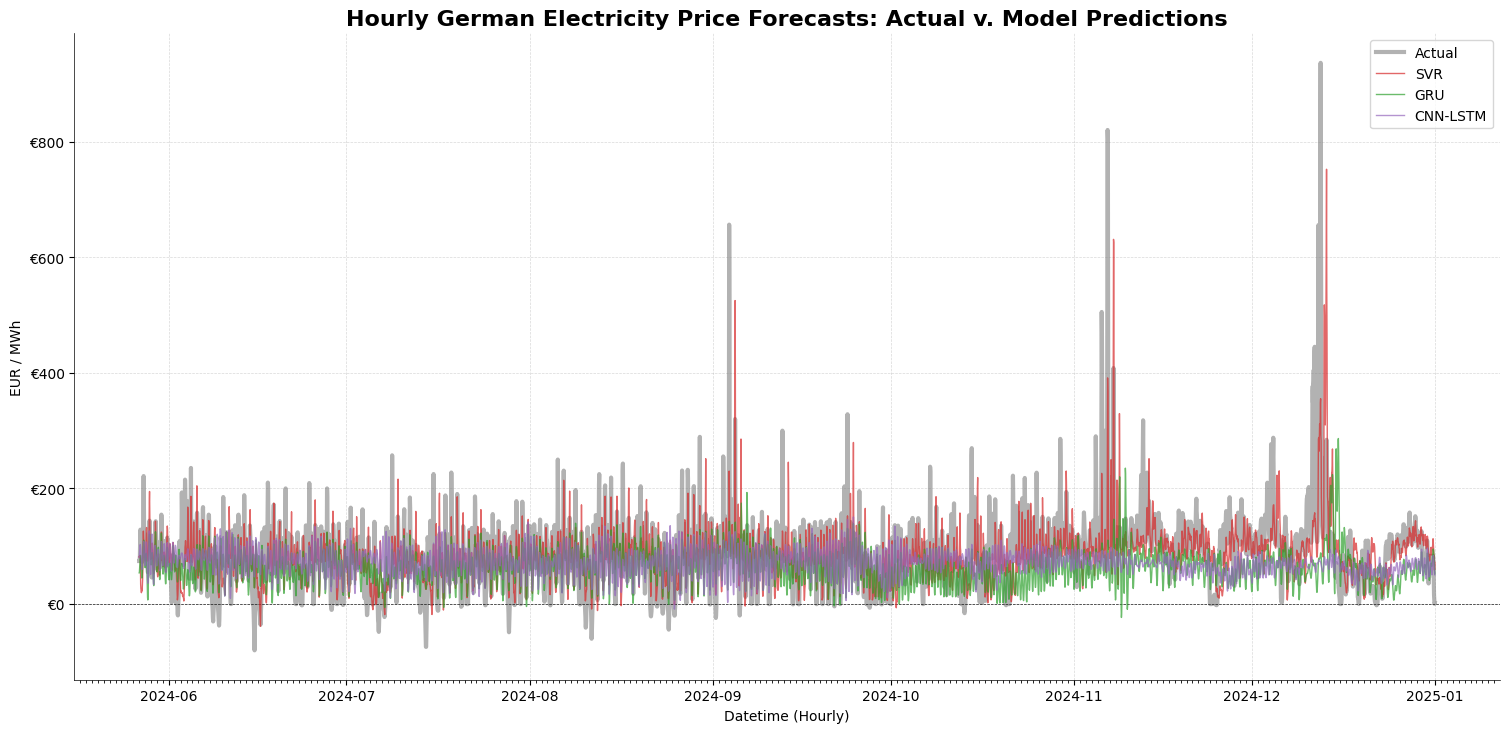

In [9]:
fig, ax = plt.subplots(figsize=(15, 7))
test_datetime = datetime[-len(y_test):]

ax.plot(test_datetime, y_test, color='black', linewidth=3, alpha=0.3, label='Actual', zorder=1)
ax.plot(test_datetime, svr_y_test_pred, color='tab:red', linewidth=1, alpha=0.7, label='SVR', zorder=2)
ax.plot(test_datetime, gru_y_test_pred, color='tab:green', linewidth=1, alpha=0.7, label='GRU', zorder=2)
ax.plot(test_datetime, cnn_lstm_y_test_pred, color='tab:purple', linewidth=1, alpha=0.7, label='CNN-LSTM', zorder=2)

ax.axhline(0, color='black', linewidth=0.5, linestyle='--', zorder=0)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_minor_locator(mdates.DayLocator())
ax.yaxis.set_major_formatter(StrMethodFormatter('€{x:,.0f}'))
ax.grid(which='major', linestyle='--', linewidth=0.5, alpha=0.3, color='gray')

ax.legend()
fig.tight_layout()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)

ax.set_xlabel('Datetime (Hourly)')
ax.set_ylabel('EUR / MWh')
ax.set_title('Hourly German Electricity Price Forecasts: Actual v. Model Predictions', fontweight='bold', fontsize=16)
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha='center')
plt.show()

In [33]:
def cum_rmse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    cum_sum_sq = np.cumsum((y_true - y_pred)**2)
    counts = np.arange(1, len(y_true)+1)
    return np.sqrt(cum_sum_sq / counts)

def cum_mae(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    cum_sum_abs = np.cumsum(np.abs(y_true - y_pred))
    counts = np.arange(1, len(y_true)+1)
    return cum_sum_abs / counts

def cum_nrmse(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    rmse = cum_rmse(y_true, y_pred)
    global_mean = np.mean(y_true)
    if global_mean == 0:
        return np.full_like(rmse, np.nan, dtype=float)
    return rmse / global_mean

def cum_rmae(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    mae = cum_mae(y_true, y_pred)
    global_mean = np.mean(y_true)
    if global_mean == 0:
        return np.full_like(mae, np.nan, dtype=float)
    return mae / global_mean

def cum_smape(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    abs_diff = np.abs(y_true - y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    ratio = np.divide(abs_diff, denom, out=np.zeros_like(abs_diff, dtype=float), where=denom != 0)
    cum_sum = np.cumsum(ratio)
    counts = np.arange(1, len(y_true)+1)
    return cum_sum / counts

def cum_apb(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    global_sum = np.sum(y_true)
    cum_num = np.cumsum(y_true - y_pred)
    if global_sum == 0:
        return np.full_like(cum_num, np.nan, dtype=float)
    return np.abs(cum_num / global_sum)

def cum_tic(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    n_total = len(y_true)
    numerator = np.sqrt(np.cumsum((y_pred - y_true)**2) / np.arange(1, n_total+1))
    global_den1 = np.sqrt(np.sum(y_true**2) / n_total)
    global_den2 = np.sqrt(np.sum(y_pred**2) / n_total)
    denominator = global_den1 + global_den2
    if denominator == 0:
        return np.full_like(numerator, np.nan, dtype=float)
    return numerator / denominator

In [34]:
score_dict = {}
mod_strs = ['SVR', 'GRU', 'CNN-LSTM']
mod_y_test_preds = [svr_y_test_pred, gru_y_test_pred, cnn_lstm_y_test_pred]
metric_strs = ['rmse', 'mae', 'nrmse', 'rmape', 'smape', 'tic', 'apb']

for metric, metric_str in zip([cum_rmse, cum_mae, cum_nrmse, cum_rmae, cum_smape, cum_tic, cum_apb], metric_strs):
    score_dict[metric_str] = {}
    for mod_str, mod_y_test_pred in zip(mod_strs, mod_y_test_preds):
        score_dict[metric_str][mod_str] = me.cumscore(y_true=y_test, y_pred=mod_y_test_pred, metric=metric)[-1]

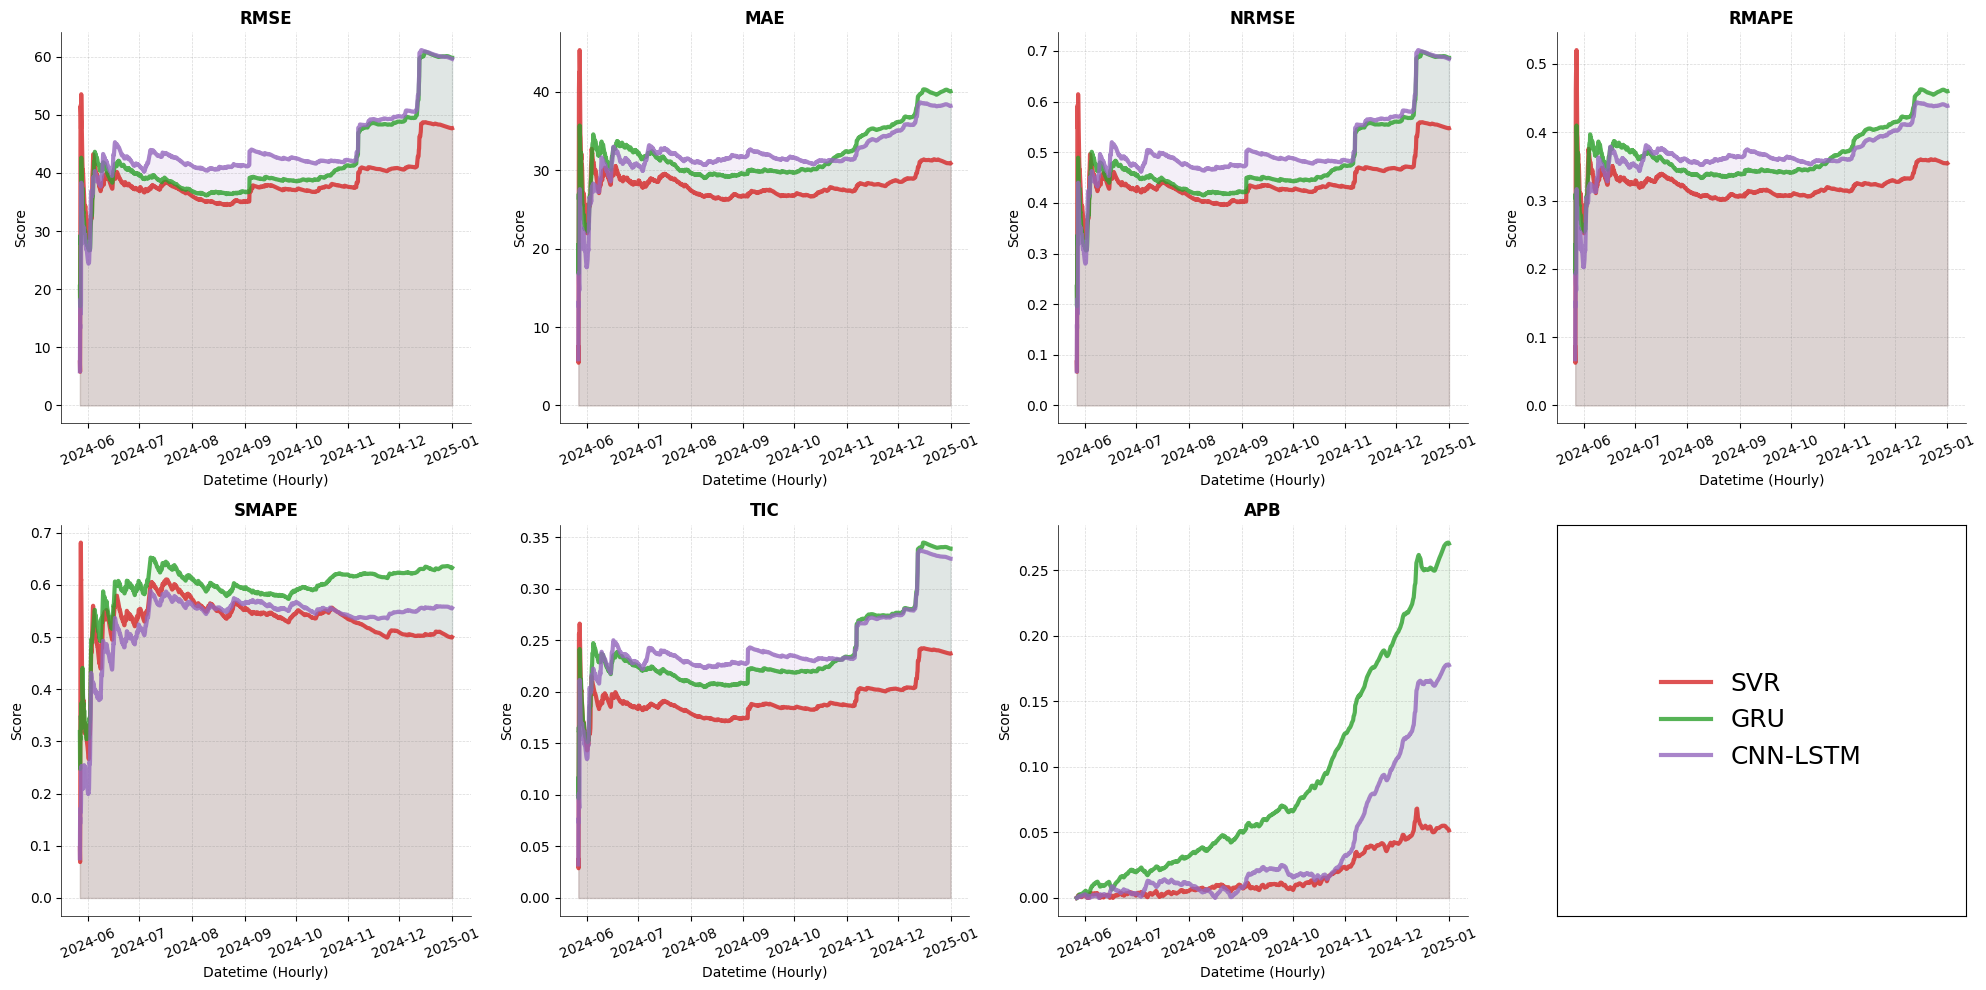

In [35]:
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()
test_datetime = datetime[-len(y_test):]
colors = ['tab:red', 'tab:green', 'tab:purple']

ax_ct = 0
for metric, metric_str in zip([cum_rmse, cum_mae, cum_nrmse, cum_rmae, cum_smape, cum_tic, cum_apb], metric_strs):
    ax = axes[ax_ct]
    ax_ct += 1
    color_ct = 0
    for mod_str, mod_y_test_pred in zip(mod_strs, mod_y_test_preds):
        ax.plot(test_datetime, score_dict[metric_str][mod_str], color=colors[color_ct], linewidth=3, alpha=0.8, label=mod_str, zorder=2)
        ax.fill_between(test_datetime, score_dict[metric_str][mod_str], color=colors[color_ct], alpha=0.1, zorder=1)
        color_ct += 1

    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.grid(which='major', linestyle='--', linewidth=0.5, alpha=0.3, color='gray')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.5)
    ax.spines['bottom'].set_linewidth(0.5)

    ax.set_xlabel('Datetime (Hourly)')
    ax.set_ylabel('Score')
    ax.set_title(metric_str.upper(), fontweight='bold', fontsize=12)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=22.5, ha='center')

legend_ax = axes[-1]
legend_ax.clear()

legend_ax.set_xticks([])
legend_ax.set_yticks([])
legend_ax.set_frame_on(True)
for spine in legend_ax.spines.values():
    spine.set_visible(True)

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, loc='center', frameon=False, fontsize=18, markerscale=2, bbox_to_anchor=(0.5, 0.5), bbox_transform=legend_ax.transAxes)

fig.tight_layout()
plt.show()